In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Các giá trị đo được từ cảm biến của máy nén khi

| Cột               | Ý nghĩa đơn giản                       |
| ----------------- | -------------------------------------- |
| `timestamp`       | Thời điểm ghi dữ liệu                  |
| `TP2`             | Áp suất khí tại đầu ra máy nén         |
| `TP3`             | Áp suất khí trong hệ thống             |
| `H1`              | Áp suất sau bộ sấy khí                 |
| `DV_pressure`     | Áp suất liên quan đến quá trình xả khí |
| `Reservoirs`      | Áp suất trong bình chứa khí            |
| `Oil_temperature` | Nhiệt độ dầu máy nén                   |
| `Motor_current`   | Dòng điện động cơ                      |


# Các trạng thái của máy nén khí

| Cột               | Ý nghĩa đơn giản            |
| ----------------- | --------------------------- |
| `COMP`            | Trạng thái máy nén          |
| `DV_eletric`      | Trạng thái van xả điện      |
| `Towers`          | Trạng thái hai tháp sấy khí |
| `MPG`             | Tín hiệu điều khiển máy nén |
| `LPS`             | Tín hiệu áp suất thấp       |
| `Pressure_switch` | Trạng thái công tắc áp suất |
| `Oil_level`       | Trạng thái mức dầu          |
| `Caudal_impulses` | Xung đo lưu lượng khí       |


# Ý nghĩa các giá trị tại 1 record

| Giá trị                  | Ý nghĩa chính xác                                                             |
| ------------------------------- | ----------------------------------------------------------------------------- |
| `timestamp = 2/1/2020 12:00 AM` | Ngày 1/2/2020, lúc 00:00                                                      |
| `TP2 = -0.012 bar`              | Áp suất tại máy nén gần bằng 0                                                |
| `TP3 = 9.358 bar`               | Áp suất tại bảng khí nén là 9,358 bar                                         |
| `H1 = 9.340 bar`                | Áp suất liên quan đến lúc bộ lọc tách nước xả                                 |
| `DV_pressure = -0.024 bar`      | Gần bằng 0. Theo tài liệu, giá trị 0 thường xuất hiện khi máy nén chạy có tải |
| `Reservoirs = 9.358 bar`        | Áp suất phía sau bình chứa; gần bằng `TP3` là đúng với mô tả                  |
| `Oil_temperature = 53.6°C`      | Nhiệt độ dầu trong máy nén                                                    |
| `Motor_current = 0.04 A`        | Gần 0 A → động cơ đang tắt                                                    |
| `COMP = 1`                      | Van hút khí đang ở trạng thái không hút khí → máy tắt hoặc chạy không tải     |
| `DV_eletric = 0`                | Van đầu ra không hoạt động → máy tắt hoặc chạy không tải                      |
| `Towers = 1`                    | Tháp sấy khí số 2 đang hoạt động                                              |
| `MPG = 1`                       | Tín hiệu điều khiển khởi động máy nén đang được kích hoạt                     |
| `LPS = 0`                       | Không có tín hiệu áp suất thấp dưới 7 bar                                     |
| `Pressure_switch = 1`           | Phát hiện hoạt động xả tại tháp sấy khí                                       |
| `Oil_level = 1`                 | Tín hiệu mức dầu thấp đang được kích hoạt                                     |
| `Caudal_impulses = 1`           | Ghi nhận xung của lượng khí đi từ APU đến bình chứa                           |


**Lưu ý: Số âm rất nhỏ do cảm biến/van do nhiễu điện từ nên không thể đúng 100%, các giá trị này sẽ được hiệu chuẩn trong thiết bị, ko cần quan tâm sai số nhỏ này.*

**> Kết luận: Tại thời điểm này, động cơ của máy nén khí đang tắt hoặc ở trạng thái không tải vì không tiêu thụ điện, bình chứa vẫn có ~9.36 bar áp suất**


In [22]:
# Cell 1 — Import thư viện và đọc toàn bộ CSV

import glob
import pandas as pd
import matplotlib.pyplot as plt

# Tìm tất cả file CSV trong Kaggle Input
csv_files = glob.glob(
    "/kaggle/input/**/*.csv",
    recursive=True
)

if len(csv_files) == 0:
    raise FileNotFoundError("Không tìm thấy file CSV trong /kaggle/input")

print("Các file CSV tìm thấy:")

for file in csv_files:
    print(file)

# Ưu tiên file có tên MetroPT3
metro_files = [
    file for file in csv_files
    if "metropt3" in file.lower()
]

if len(metro_files) > 0:
    file_path = metro_files[0]
else:
    file_path = csv_files[0]

print("\nFile được chọn:")
print(file_path)

# Đọc toàn bộ dataset
df = pd.read_csv(file_path)

# Xóa khoảng trắng trong tên cột
df.columns = df.columns.str.strip()

# Xóa cột số thứ tự thừa nếu có
df = df.drop(
    columns=["Unnamed: 0"],
    errors="ignore"
)

# Chuyển timestamp thành kiểu thời gian
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    format="%Y-%m-%d %H:%M:%S",
    errors="raise"
)

print("\nĐọc dữ liệu thành công")
print("Số record:", df.shape[0])
print("Số cột:", df.shape[1])
print("Thời điểm đầu:", df["timestamp"].min())
print("Thời điểm cuối:", df["timestamp"].max())

Các file CSV tìm thấy:
/kaggle/input/datasets/nargesdavari/metropt3-air-compressor/MetroPT3(CompressorDatase).csv

File được chọn:
/kaggle/input/datasets/nargesdavari/metropt3-air-compressor/MetroPT3(CompressorDatase).csv

Đọc dữ liệu thành công
Số record: 15169480
Số cột: 16
Thời điểm đầu: 2020-02-01 00:00:00
Thời điểm cuối: 2020-09-01 03:59:59


In [23]:
# Cell 2 — Kiểm tra dữ liệu ban đầu

print("5 record đầu tiên:")
display(df.head())

print("\nKiểu dữ liệu:")
print(df.dtypes)

print("\nSố ô bị thiếu:")
print(df.isnull().sum())

5 record đầu tiên:


,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,2020-02-01 00:00:01,-0.012,9.358,9.342,-0.022,9.360,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,2020-02-01 00:00:02,-0.012,9.356,9.340,-0.022,9.358,53.625,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,2020-02-01 00:00:03,-0.012,9.356,9.340,-0.022,9.358,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,2020-02-01 00:00:04,-0.012,9.354,9.338,-0.022,9.356,53.625,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0



Kiểu dữ liệu:
timestamp          datetime64[ns]
TP2                       float64
TP3                       float64
H1                        float64
DV_pressure               float64
Reservoirs                float64
Oil_temperature           float64
Motor_current             float64
COMP                      float64
DV_eletric                float64
Towers                    float64
MPG                       float64
LPS                       float64
Pressure_switch           float64
Oil_level                 float64
Caudal_impulses           float64
dtype: object

Số ô bị thiếu:
timestamp          0
TP2                0
TP3                0
H1                 0
DV_pressure        0
Reservoirs         0
Oil_temperature    0
Motor_current      0
COMP               0
DV_eletric         0
Towers             0
MPG                0
LPS                0
Pressure_switch    0
Oil_level          0
Caudal_impulses    0
dtype: int64


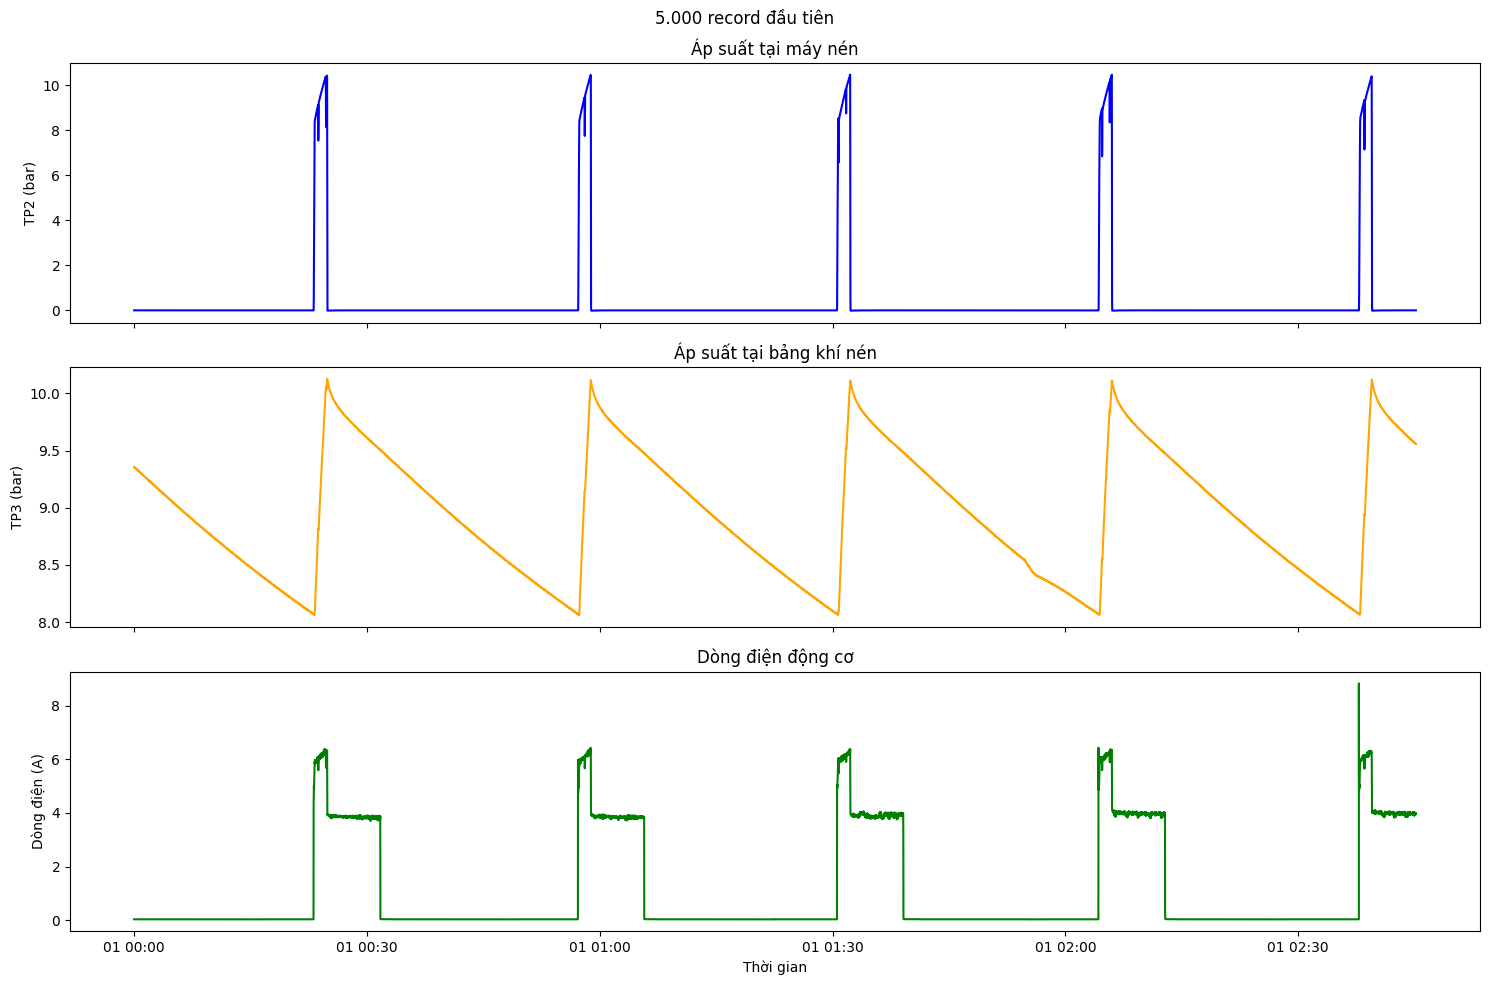

In [25]:
# Cell 3 — Vẽ 10.000 record đầu tiên
# Lấy 5.000 record đầu
sample = df.iloc[:10000]

fig, axes = plt.subplots(
    3,
    1,
    figsize=(15, 10),
    sharex=True
)

# TP2
axes[0].plot(
    sample["timestamp"],
    sample["TP2"],
    color="blue"
)

axes[0].set_title("Áp suất tại máy nén")
axes[0].set_ylabel("TP2 (bar)")

# TP3
axes[1].plot(
    sample["timestamp"],
    sample["TP3"],
    color="orange"
)

axes[1].set_title("Áp suất tại bảng khí nén")
axes[1].set_ylabel("TP3 (bar)")

# Dòng điện động cơ
axes[2].plot(
    sample["timestamp"],
    sample["Motor_current"],
    color="green"
)

axes[2].set_title("Dòng điện động cơ")
axes[2].set_ylabel("Dòng điện (A)")
axes[2].set_xlabel("Thời gian")

fig.suptitle("5.000 record đầu tiên")

plt.tight_layout()
plt.show()

In [26]:
# Cell 4 — Gắn nhãn cho đủ 4 khoảng rò khí
# Đặt tất cả record về nhãn 0
df["label"] = 0

# 4 khoảng rò khí từ báo cáo bảo trì
fault_periods = [
    # Lỗi 1
    ("2020-04-18 00:00:00", "2020-04-19 00:00:00"),

    # Lỗi 2
    ("2020-05-29 23:30:00", "2020-05-30 06:01:00"),

    # Lỗi 3
    ("2020-06-05 10:00:00", "2020-06-07 14:31:00"),

    # Lỗi 4
    ("2020-07-15 14:30:00", "2020-07-15 19:01:00")
]

for number, (start, end) in enumerate(
    fault_periods,
    start=1
):
    mask = (
        (df["timestamp"] >= pd.Timestamp(start)) &
        (df["timestamp"] < pd.Timestamp(end))
    )

    df.loc[mask, "label"] = 1

    print(
        f"Khoảng lỗi {number}: "
        f"{mask.sum():,} record"
    )

print("\nTổng số record theo nhãn:")
print(df["label"].value_counts())

Khoảng lỗi 1: 86,625 record
Khoảng lỗi 2: 23,664 record
Khoảng lỗi 3: 173,145 record
Khoảng lỗi 4: 16,270 record

Tổng số record theo nhãn:
label
0    14869776
1      299704
Name: count, dtype: int64


Số record: 3632
Thời điểm đầu: 2020-04-18 23:00:00
Thời điểm cuối: 2020-04-18 23:59:59


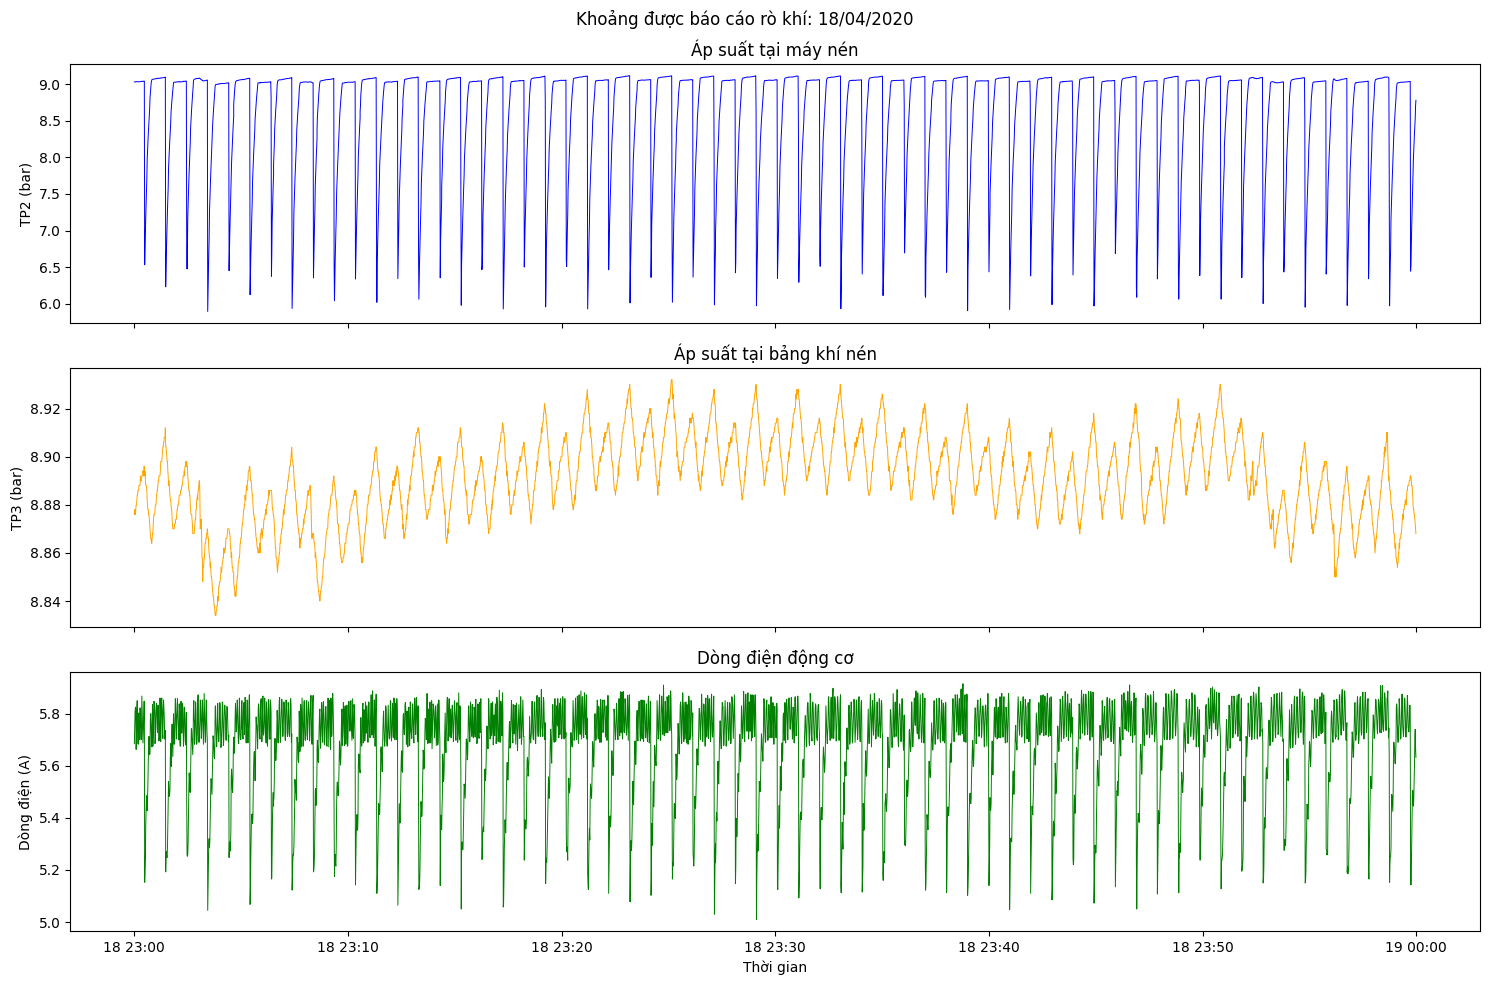

In [28]:
# Cell 5 — Lấy và vẽ khoảng rò khí đầu tiên
fault_start = pd.Timestamp(
    "2020-04-18 23:00:00"
)

fault_end = pd.Timestamp(
    "2020-04-19 00:00:00"
)

# Lấy các record trong khoảng lỗi đầu
fault_1 = df[
    (df["timestamp"] >= fault_start) &
    (df["timestamp"] < fault_end)
].copy()

print("Số record:", len(fault_1))
print("Thời điểm đầu:", fault_1["timestamp"].min())
print("Thời điểm cuối:", fault_1["timestamp"].max())

fig, axes = plt.subplots(
    3,
    1,
    figsize=(15, 10),
    sharex=True
)

axes[0].plot(
    fault_1["timestamp"],
    fault_1["TP2"],
    color="blue",
    linewidth=0.7
)

axes[0].set_title("Áp suất tại máy nén")
axes[0].set_ylabel("TP2 (bar)")

axes[1].plot(
    fault_1["timestamp"],
    fault_1["TP3"],
    color="orange",
    linewidth=0.7
)

axes[1].set_title("Áp suất tại bảng khí nén")
axes[1].set_ylabel("TP3 (bar)")

axes[2].plot(
    fault_1["timestamp"],
    fault_1["Motor_current"],
    color="green",
    linewidth=0.7
)

axes[2].set_title("Dòng điện động cơ")
axes[2].set_ylabel("Dòng điện (A)")
axes[2].set_xlabel("Thời gian")

fig.suptitle(
    "Khoảng được báo cáo rò khí: 18/04/2020"
)

plt.tight_layout()
plt.show()

In [30]:
# Cell 6 — Tạo bảng mới gộp theo 5 phút (300 record)

# Chỉ lấy các cột cần dùng cho mô hình đầu tiên
data = df[
    [
        "timestamp",
        "TP2",
        "TP3",
        "Motor_current",
        "label"
    ]
].copy()

# 1 = động cơ chạy, 0 = động cơ tắt
data["Motor_running"] = (
    data["Motor_current"] > 1
).astype("uint8")

# Gom theo từng khoảng 5 phút
df_5min = (
    data.set_index("timestamp")
        .resample("5min")
        .agg(
            # TP2
            TP2_mean=("TP2", "mean"),
            TP2_min=("TP2", "min"),
            TP2_max=("TP2", "max"),
            TP2_std=("TP2", "std"),

            # TP3
            TP3_mean=("TP3", "mean"),
            TP3_min=("TP3", "min"),
            TP3_max=("TP3", "max"),
            TP3_std=("TP3", "std"),

            # Dòng điện
            Motor_current_mean=(
                "Motor_current",
                "mean"
            ),
            Motor_current_min=(
                "Motor_current",
                "min"
            ),
            Motor_current_max=(
                "Motor_current",
                "max"
            ),
            Motor_current_std=(
                "Motor_current",
                "std"
            ),

            # Tỷ lệ thời gian động cơ chạy
            Motor_running_ratio=(
                "Motor_running",
                "mean"
            ),

            # Một record lỗi → khoảng 5 phút có nhãn 1
            label=("label", "max")
        )
        .dropna()
        .reset_index()
)

# Chuyển label về số nguyên
df_5min["label"] = (
    df_5min["label"].astype(int)
)

print("Kích thước dữ liệu gốc:", df.shape)
print("Kích thước dữ liệu 5 phút:", df_5min.shape)

print("\nSố khoảng theo nhãn:")
print(df_5min["label"].value_counts())

columns_to_view = [
    "timestamp",
    "TP2_mean",
    "TP2_max",
    "TP3_min",
    "TP3_max",
    "Motor_current_mean",
    "Motor_current_max",
    "Motor_running_ratio",
    "label"
]

display(
    df_5min[columns_to_view].head(10)
)

Kích thước dữ liệu gốc: (15169480, 17)
Kích thước dữ liệu 5 phút: (50787, 15)

Số khoảng theo nhãn:
label
0    49791
1      996
Name: count, dtype: int64


,timestamp,TP2_mean,TP2_max,TP3_min,TP3_max,Motor_current_mean,Motor_current_max,Motor_running_ratio,label
0,2020-02-01 00:00:00,-0.012594,-0.012,9.048,9.358,0.040107,0.0425,0.000000,0
1,2020-02-01 00:05:00,-0.013545,-0.012,8.754,9.046,0.039959,0.0425,0.000000,0
2,2020-02-01 00:10:00,-0.013768,-0.012,8.480,8.754,0.039859,0.0425,0.000000,0
3,2020-02-01 00:15:00,-0.013960,-0.012,8.222,8.480,0.039703,0.0425,0.000000,0
4,2020-02-01 00:20:00,3.171311,10.434,8.062,10.126,2.227492,6.3825,0.374172,0
5,2020-02-01 00:25:00,-0.014086,-0.010,9.614,10.086,3.861097,3.9475,1.000000,0
6,2020-02-01 00:30:00,-0.012185,-0.010,9.302,9.612,1.353168,3.9100,0.346535,0
7,2020-02-01 00:35:00,-0.013122,-0.012,8.992,9.300,0.039950,0.0425,0.000000,0
8,2020-02-01 00:40:00,-0.013768,-0.012,8.700,8.992,0.039719,0.0425,0.000000,0
9,2020-02-01 00:45:00,-0.014040,-0.012,8.430,8.702,0.039736,0.0425,0.000000,0


In [31]:
# Cell 8 — Chia train và test
# Mốc chia hết tháng 2
split_time = pd.Timestamp(
    "2020-03-01 00:00:00"
)

# Dữ liệu huấn luyện
train_5min = df_5min[
    df_5min["timestamp"] < split_time
].copy()

# Dữ liệu kiểm tra
test_5min = df_5min[
    df_5min["timestamp"] >= split_time
].copy()

# Tất cả cột dùng làm đầu vào mô hình
feature_columns = [
    column
    for column in df_5min.columns
    if column not in ["timestamp", "label"]
]

# Dữ liệu đưa cho mô hình học
X_train = train_5min[feature_columns]

# Dữ liệu để mô hình dự đoán
X_test = test_5min[feature_columns]

# Đáp án test giữ riêng
y_test = test_5min["label"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nCác cột mô hình được nhìn thấy:")
print(X_train.columns.tolist())

print("\nNhãn trong train:")
print(train_5min["label"].value_counts())

print("\nNhãn trong test:")
print(y_test.value_counts())

X_train: (7137, 13)
X_test: (43650, 13)
y_test: (43650,)

Các cột mô hình được nhìn thấy:
['TP2_mean', 'TP2_min', 'TP2_max', 'TP2_std', 'TP3_mean', 'TP3_min', 'TP3_max', 'TP3_std', 'Motor_current_mean', 'Motor_current_min', 'Motor_current_max', 'Motor_current_std', 'Motor_running_ratio']

Nhãn trong train:
label
0    7137
Name: count, dtype: int64

Nhãn trong test:
label
0    42654
1      996
Name: count, dtype: int64


**Đọc dữ liệu**
- đọc hiểu cảm biến
- gắn nhãn theo instruction
- gom theo 5 phút 9300 records)
- chia train/test